# Evaluate Structure-Based Mechanical Predictor on ColabFold Predicted Structures

This notebook tests the intended pipeline:

```text
spider silk sequence -> ColabFold predicted structure -> hbond/topology features -> mechanical-property prediction -> correlation with measured properties
```

The dataset can contain many candidate silk-protein sequences for one measured spider silk sample. Therefore the notebook reports both sequence-level predictions and idv-level aggregate predictions when predicted PDB files are available.


## Important Notes

- `mechanical_properties.csv` contains measured sample-level properties.
- FASTA files in `raw_data/` are matched to measurements by the second underscore-separated field in the filename, which corresponds to `idv_id`.
- Full ColabFold prediction is expensive. In this repository snapshot, 289 measured samples match 3725 FASTA files, with lengths from 79 to 1854 aa.
- ColabFold requires AlphaFold/ColabFold model parameters. If they are not already cached, the first run downloads about 3.47 GB.
- The current hbond/topology predictor was trained on explicit-hydrogen PDB structures. Unrelaxed ColabFold PDB files usually do not contain hydrogens, so this notebook uses `--amber --num-relax 1` when structure prediction is launched from the notebook.


In [5]:
from __future__ import annotations

import json
import math
import os
import re
import shutil
import subprocess
import sys
from dataclasses import asdict
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'model').is_dir() and (candidate / 'README.md').exists():
            return candidate
    return start

REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

CSV_PATH = Path('/home/jianquanzhao/git_reps/spider_silk_codes/mechanical_properties.csv')
RAW_DATA_DIR = Path('/home/jianquanzhao/git_reps/spider_silk_codes/raw_data')

OUT_DIR = REPO_ROOT / 'output/evaluate-mechanical-predictor'
PDB_COLAB_DIR = OUT_DIR / 'pdb-colab'
FIGURE_DIR = OUT_DIR / 'figures'
TABLE_DIR = OUT_DIR / 'tables'
COLABFOLD_DATA_DIR = OUT_DIR / 'colabfold-local-data'
COLABFOLD_INPUT_DIR = PDB_COLAB_DIR / 'input-fasta'
COLABFOLD_RESULT_DIR = PDB_COLAB_DIR / 'results'

COLABFOLD_BIN = Path('/mnt/data1/home/jianquanzhao/anaconda24/envs/colabfold/bin/colabfold_batch')
CUDA_HOME = Path('/mnt/data2/jianquanzhao/cuda/cuda-12.8')
LOCAL_AFDB_PARAMS_DIR = Path('/mnt/nas/jianquanzhao/afdb/params')

for path in [PDB_COLAB_DIR, FIGURE_DIR, TABLE_DIR, COLABFOLD_DATA_DIR, COLABFOLD_INPUT_DIR, COLABFOLD_RESULT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if LOCAL_AFDB_PARAMS_DIR.exists():
    local_params_dir = COLABFOLD_DATA_DIR / 'params'
    local_params_dir.mkdir(parents=True, exist_ok=True)
    for source_file in LOCAL_AFDB_PARAMS_DIR.iterdir():
        if not source_file.is_file():
            continue
        link_path = local_params_dir / source_file.name
        if link_path.exists() or link_path.is_symlink():
            continue
        link_path.symlink_to(source_file)
    (local_params_dir / 'download_finished.txt').write_text(
        f'local params from {LOCAL_AFDB_PARAMS_DIR}\n', encoding='utf-8'
    )

# Safety switches. Set RUN_COLABFOLD=True only when ColabFold parameters are ready
# or when you intentionally want to download/run prediction.
RUN_COLABFOLD = True
MAX_COLABFOLD_SEQUENCES: Optional[int] = None  # Set None for all matched sequences.
MAX_SEQUENCE_LENGTH_FOR_SMOKE = 180

print('CSV exists:', CSV_PATH.exists(), CSV_PATH)
print('Raw data exists:', RAW_DATA_DIR.exists(), RAW_DATA_DIR)
print('ColabFold binary exists:', COLABFOLD_BIN.exists(), COLABFOLD_BIN)
print('Output dir:', OUT_DIR.resolve())


CSV exists: True /home/jianquanzhao/git_reps/spider_silk_codes/mechanical_properties.csv
Raw data exists: True /home/jianquanzhao/git_reps/spider_silk_codes/raw_data
ColabFold binary exists: True /mnt/data1/home/jianquanzhao/anaconda24/envs/colabfold/bin/colabfold_batch
Output dir: /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor


## 1. Parse measured mechanical properties and matched FASTA sequences


In [2]:
def read_fasta(path: Path) -> tuple[str, str]:
    header = ''
    seq_parts = []
    for line in path.read_text(encoding='utf-8', errors='ignore').splitlines():
        line = line.strip()
        if not line:
            continue
        if line.startswith('>'):
            if not header:
                header = line[1:]
            continue
        seq_parts.append(line)
    seq = ''.join(seq_parts).replace('*', '').upper()
    seq = re.sub(r'[^A-Z]', '', seq)
    return header, seq


def parse_fasta_filename(path: Path) -> dict:
    stem = path.name
    if stem.endswith('.aa.fasta'):
        stem = stem[:-len('.aa.fasta')]
    parts = stem.split('_')
    seq_file_id = parts[0] if parts else ''
    idv_id = parts[1] if len(parts) > 1 else ''
    silk_type = parts[-1] if parts else ''
    return {
        'fasta_path': str(path),
        'fasta_name': path.name,
        'seq_file_id': seq_file_id,
        'idv_id': idv_id,
        'silk_type_from_name': silk_type,
    }

properties = pd.read_csv(CSV_PATH)
properties['idv_id'] = properties['idv_id'].astype(str)
valid_properties = properties.dropna(subset=['toughness', 'tensile_strength']).copy()
valid_idv_ids = set(valid_properties['idv_id'])

records = []
for fasta_path in sorted(RAW_DATA_DIR.glob('*.fasta')):
    meta = parse_fasta_filename(fasta_path)
    if meta['idv_id'] not in valid_idv_ids:
        continue
    header, sequence = read_fasta(fasta_path)
    if not sequence:
        continue
    prop_rows = valid_properties[valid_properties['idv_id'] == meta['idv_id']]
    if prop_rows.empty:
        continue
    prop = prop_rows.iloc[0].to_dict()
    record = {**meta}
    record.update({
        'header': header,
        'sequence': sequence,
        'sequence_length': len(sequence),
        'measured_toughness': float(prop['toughness']),
        'measured_tensile_strength': float(prop['tensile_strength']),
        'family': prop.get('family'),
        'genus': prop.get('genus'),
        'species': prop.get('species'),
        'sampled_at': prop.get('sampled_at'),
        'country': prop.get('country'),
    })
    records.append(record)

seq_df = pd.DataFrame(records)
seq_df['job_id'] = seq_df['fasta_name'].str.replace(r'[^A-Za-z0-9_.-]+', '_', regex=True).str.replace('.aa.fasta', '', regex=False)
seq_df.to_csv(TABLE_DIR / 'matched_sequences.csv', index=False)

summary = {
    'n_mechanical_rows': int(len(properties)),
    'n_rows_with_toughness_and_tensile_strength': int(len(valid_properties)),
    'n_matched_sequences': int(len(seq_df)),
    'n_matched_idv': int(seq_df['idv_id'].nunique()) if not seq_df.empty else 0,
    'sequence_length_min': int(seq_df['sequence_length'].min()) if not seq_df.empty else None,
    'sequence_length_max': int(seq_df['sequence_length'].max()) if not seq_df.empty else None,
    'sequence_length_mean': float(seq_df['sequence_length'].mean()) if not seq_df.empty else None,
}
print(json.dumps(summary, indent=2, ensure_ascii=False))
seq_df.head()


{
  "n_mechanical_rows": 446,
  "n_rows_with_toughness_and_tensile_strength": 393,
  "n_matched_sequences": 3513,
  "n_matched_idv": 268,
  "sequence_length_min": 79,
  "sequence_length_max": 1854,
  "sequence_length_mean": 490.32678622260175
}


,fasta_path,fasta_name,seq_file_id,idv_id,silk_type_from_name,header,sequence,sequence_length,measured_toughness,measured_tensile_strength,family,genus,species,sampled_at,country,job_id
0,/home/jianquanzhao/git_reps/spider_silk_codes/...,10001_5842_Clubionidae_Clubiona_vigil_MiSp_nte...,10001,5842,nterm,10001|5842|Clubionidae|Clubiona|vigil|MiSp|MiS...,MGFSTRIAIPLLALLVSALPDITLGQSSNTPWANPNLLENFMGSFM...,209,0.233,3.33,Clubionidae,Clubiona,vigil,2017-07-12,Japan,10001_5842_Clubionidae_Clubiona_vigil_MiSp_nterm
1,/home/jianquanzhao/git_reps/spider_silk_codes/...,10006_6823_Clubionidae_Clubiona_sp_OTU0921_MiS...,10006,6823,nterm,10006|6823|Clubionidae|Clubiona|sp. (OTU0921)|...,MGFSTRLAIPLIALLVSALPNLTSGQASNTPWSSPQLMEKFMGSFM...,358,0.103,0.54,Clubionidae,Clubiona,sp. (OTU0921),2017-11-04,Australia,10006_6823_Clubionidae_Clubiona_sp_OTU0921_MiS...
2,/home/jianquanzhao/git_reps/spider_silk_codes/...,1000_6796_Araneidae_Argiope_keyserlingi_AcSp_c...,1000,6796,cterm,1000|6796|Araneidae|Argiope|keyserlingi|AcSp|A...,SESRARSESRGQSGARSESVSRQSSFGQTSGFSGSTGGQSGFSQTM...,729,0.202,1.59,Araneidae,Argiope,keyserlingi,2017-10-31,Australia,1000_6796_Araneidae_Argiope_keyserlingi_AcSp_c...
3,/home/jianquanzhao/git_reps/spider_silk_codes/...,10014_4269_Clubionidae_Clubiona_riparia_MiSp_n...,10014,4269,nterm,10014|4269|Clubionidae|Clubiona|riparia|MiSp|M...,MGFSTRLAIPLIALLVSALPDITSGQASSNTPWSSPQLMEQFMNSF...,275,0.062,1.64,Clubionidae,Clubiona,riparia,2016-08-05,Japan,10014_4269_Clubionidae_Clubiona_riparia_MiSp_n...
4,/home/jianquanzhao/git_reps/spider_silk_codes/...,10035_4269_Clubionidae_Clubiona_riparia_MiSp_n...,10035,4269,nterm,10035|4269|Clubionidae|Clubiona|riparia|MiSp|M...,MIWSSRLAIPLLLFVVSAIASGQSTSNTPWSSPQVMETFMNSFMSS...,310,0.062,1.64,Clubionidae,Clubiona,riparia,2016-08-05,Japan,10035_4269_Clubionidae_Clubiona_riparia_MiSp_n...


## 2. Data overview figures


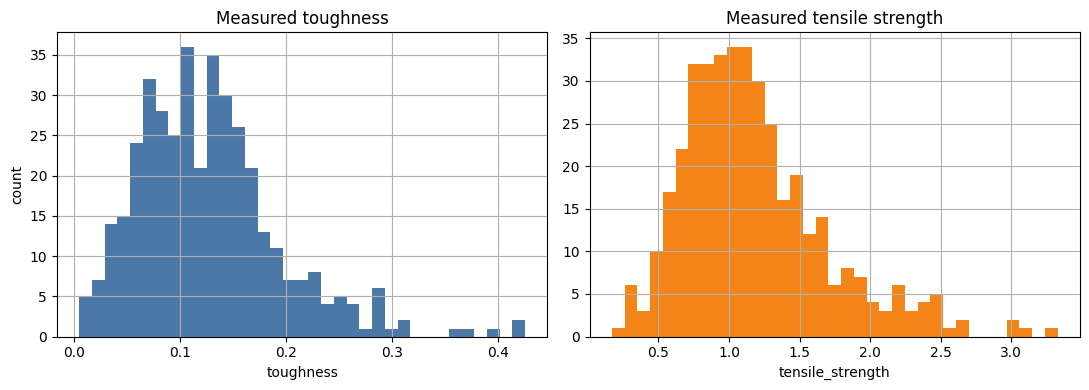

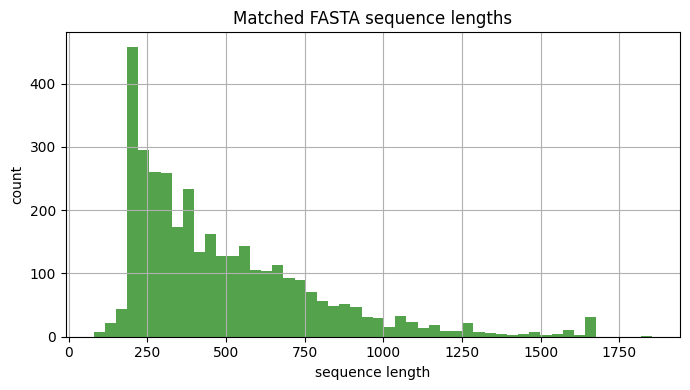

In [3]:
plt.style.use('default')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
valid_properties['toughness'].dropna().hist(ax=axes[0], bins=35, color='#4C78A8')
axes[0].set_title('Measured toughness')
axes[0].set_xlabel('toughness')
axes[0].set_ylabel('count')
valid_properties['tensile_strength'].dropna().hist(ax=axes[1], bins=35, color='#F58518')
axes[1].set_title('Measured tensile strength')
axes[1].set_xlabel('tensile_strength')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'measured_property_distributions.png', dpi=200)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
seq_df['sequence_length'].hist(ax=ax, bins=50, color='#54A24B')
ax.set_title('Matched FASTA sequence lengths')
ax.set_xlabel('sequence length')
ax.set_ylabel('count')
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'matched_sequence_length_distribution.png', dpi=200)
plt.show()


## 3. Prepare and optionally run ColabFold

The cell below writes FASTA files for the selected evaluation subset. By default, it selects a few short sequences for smoke testing. For full evaluation, set:

```python
RUN_COLABFOLD = True
MAX_COLABFOLD_SEQUENCES = None
MAX_SEQUENCE_LENGTH_FOR_SMOKE = None
```

Full prediction can take a long time and requires ColabFold model parameters.


In [4]:
def write_colabfold_fastas(input_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in input_df.iterrows():
        fasta_out = COLABFOLD_INPUT_DIR / f"{row['job_id']}.fasta"
        fasta_out.write_text(f">{row['job_id']}\n{row['sequence']}\n", encoding='utf-8')
        rows.append({**row.to_dict(), 'colabfold_input_fasta': str(fasta_out)})
    return pd.DataFrame(rows)

candidate_df = seq_df.copy()
# if MAX_SEQUENCE_LENGTH_FOR_SMOKE is not None:
    # candidate_df = candidate_df[candidate_df['sequence_length'] <= MAX_SEQUENCE_LENGTH_FOR_SMOKE]
# candidate_df = candidate_df.sort_values(['sequence_length', 'idv_id', 'fasta_name'])
# if MAX_COLABFOLD_SEQUENCES is not None:
    # candidate_df = candidate_df.head(MAX_COLABFOLD_SEQUENCES)

colab_input_df = write_colabfold_fastas(candidate_df)
colab_input_df.to_csv(TABLE_DIR / 'colabfold_input_sequences.csv', index=False)

cmd = [
    str(COLABFOLD_BIN),
    '--data', str(COLABFOLD_DATA_DIR),
    '--msa-mode', 'single_sequence',
    '--model-type', 'alphafold2_ptm',
    '--num-models', '1',
    '--num-recycle', '1',
    '--amber',
    '--num-relax', '1',
    '--use-pallas', 'false',
    '--compile-mode', 'fast',
    '--overwrite-existing-results',
    str(COLABFOLD_INPUT_DIR),
    str(COLABFOLD_RESULT_DIR),
]
print('Selected sequences for ColabFold:', len(colab_input_df))
print('Command:')
print(' '.join(cmd))

if RUN_COLABFOLD:
    run_env = dict(os.environ)
    run_env['CUDA_PATH'] = str(CUDA_HOME)
    run_env['PATH'] = f"{CUDA_HOME / 'bin'}:{run_env.get('PATH', '')}"
    completed = subprocess.run(cmd, check=False, text=True, capture_output=True, env=run_env)
    (OUT_DIR / 'colabfold_stdout.log').write_text(completed.stdout, encoding='utf-8')
    (OUT_DIR / 'colabfold_stderr.log').write_text(completed.stderr, encoding='utf-8')
    print('ColabFold return code:', completed.returncode)
    if completed.returncode != 0:
        print(completed.stderr[-3000:])
else:
    print('RUN_COLABFOLD=False; prediction was not launched from this notebook run.')


Selected sequences for ColabFold: 3513
Command:
/mnt/data1/home/jianquanzhao/anaconda24/envs/colabfold/bin/colabfold_batch --data /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/colabfold-local-data --msa-mode single_sequence --model-type alphafold2_ptm --num-models 1 --num-recycle 1 --amber --num-relax 1 --use-pallas false --compile-mode fast --overwrite-existing-results /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/pdb-colab/input-fasta /mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/pdb-colab/results
RUN_COLABFOLD=False; prediction was not launched from this notebook run.


## 4. Locate predicted PDB files


In [5]:
def find_best_colabfold_pdb(job_id: str) -> Optional[Path]:
    patterns = [
        f'{job_id}*rank_001*.pdb',
        f'{job_id}*unrelaxed*.pdb',
        f'{job_id}*.pdb',
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(COLABFOLD_RESULT_DIR.rglob(pattern))
    candidates = sorted(set(candidates))
    return candidates[0] if candidates else None

pdb_rows = []
for _, row in seq_df.iterrows():
    pdb_path = find_best_colabfold_pdb(row['job_id'])
    if pdb_path is None:
        continue
    pdb_rows.append({**row.to_dict(), 'predicted_pdb_path': str(pdb_path)})

pdb_df = pd.DataFrame(pdb_rows)
if pdb_df.empty:
    pdb_df = seq_df.head(0).copy()
    pdb_df['predicted_pdb_path'] = pd.Series(dtype='object')
pdb_df.to_csv(TABLE_DIR / 'colabfold_predicted_pdb_index.csv', index=False)
print('Predicted PDB files found:', len(pdb_df))
pdb_df.head()


Predicted PDB files found: 3


,fasta_path,fasta_name,seq_file_id,idv_id,silk_type_from_name,header,sequence,sequence_length,measured_toughness,measured_tensile_strength,family,genus,species,sampled_at,country,job_id,predicted_pdb_path
0,/home/jianquanzhao/git_reps/spider_silk_codes/...,6370_4109_Tetragnathidae_Metleucauge_kompirens...,6370,4109,nterm,6370|4109|Tetragnathidae|Metleucauge|kompirens...,MDWLSCTAFLLALSSVWYEPTIAQSVVVSVPPVFSSPQLANGFLDC...,100,0.078,0.94,Tetragnathidae,Metleucauge,kompirensis,2016-07-28,Japan,6370_4109_Tetragnathidae_Metleucauge_kompirens...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
1,/home/jianquanzhao/git_reps/spider_silk_codes/...,6778_3900_Araneidae_Eustala_anastera_AgSp1_nte...,6778,3900,nterm,6778|3900|Araneidae|Eustala|anastera|AgSp1|AgS...,MGWLSHVIVLFCVVGTQLKTAYSQQNYQPGIGIVQDDPLLDEDTGE...,94,0.106,0.91,Araneidae,Eustala,anastera,2016-07-02,United States,6778_3900_Araneidae_Eustala_anastera_AgSp1_nterm,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...
2,/home/jianquanzhao/git_reps/spider_silk_codes/...,6999_3943_Tetragnathidae_Tetragnatha_sp_OTU093...,6999,3943,nterm,6999|3943|Tetragnathidae|Tetragnatha|sp. (OTU0...,MGWISHVLVVLSVVGFQLTAAKKSYRPGIGIVQDDPLLDQQTGKDF...,79,0.148,1.30,Tetragnathidae,Tetragnatha,sp. (OTU0935),2016-07-03,United States,6999_3943_Tetragnathidae_Tetragnatha_sp_OTU093...,/mnt/nas/jianquanzhao/gits/Mechanical-protein-...


## 5. Run the hbond/topology mechanical-property predictor


In [6]:
from model.reward_module.terminal_reward import HbondTopologyTerminalRewardCalculator, TerminalRewardScalarization

predictor = HbondTopologyTerminalRewardCalculator(
    scalarization=TerminalRewardScalarization(
        strength_weight=1.0,
        toughness_weight=1.0,
        disagreement_penalty=0.25,
    )
)

prediction_rows = []
for _, row in pdb_df.iterrows():
    try:
        result = predictor.evaluate_pdb(row['predicted_pdb_path'])
        record = {**row.to_dict()}
        record.update({
            'predicted_toughness': result.toughness,
            'predicted_strength': result.strength,
            'terminal_reward': result.reward,
            'normalized_toughness': result.normalized_toughness,
            'normalized_strength': result.normalized_strength,
            'hbond_count': result.feature_diagnostics.get('hbond_count'),
            'hydrogen_atom_count': result.feature_diagnostics.get('hydrogen_atom_count'),
            'mean_plddt': result.feature_diagnostics.get('mean_plddt'),
            'feature_warnings': ';'.join(result.feature_diagnostics.get('warnings', ())),
        })
        for key, value in result.features.items():
            record[f'feature_{key}'] = value
        prediction_rows.append(record)
    except Exception as exc:
        record = {**row.to_dict(), 'prediction_error': repr(exc)}
        prediction_rows.append(record)

prediction_columns = list(pdb_df.columns) + [
    'predicted_toughness', 'predicted_strength', 'terminal_reward',
    'normalized_toughness', 'normalized_strength', 'hbond_count',
    'hydrogen_atom_count', 'mean_plddt', 'feature_warnings', 'prediction_error',
]
pred_df = pd.DataFrame(prediction_rows)
if pred_df.empty:
    pred_df = pd.DataFrame(columns=prediction_columns)
pred_df.to_csv(TABLE_DIR / 'predicted_mechanical_properties.csv', index=False)
print('Predicted rows:', len(pred_df))
if len(pred_df):
    display(pred_df.head())
else:
    print('No predictions were generated because no ColabFold PDB files were found.')


Predicted rows: 3


,fasta_path,fasta_name,seq_file_id,idv_id,silk_type_from_name,header,sequence,sequence_length,measured_toughness,measured_tensile_strength,...,hydrogen_atom_count,mean_plddt,feature_warnings,feature_sequence_length,feature_hbond_per_residue,feature_seq_class_nonlocal_per_residue,feature_strong_nonlocal_fraction,feature_strong_nonlocal_per_residue,feature_nonlocal_backbone_backbone_per_residue,feature_hbond_contact_order
0,/home/jianquanzhao/git_reps/spider_silk_codes/...,6370_4109_Tetragnathidae_Metleucauge_kompirens...,6370,4109,nterm,6370|4109|Tetragnathidae|Metleucauge|kompirens...,MDWLSCTAFLLALSSVWYEPTIAQSVVVSVPPVFSSPQLANGFLDC...,100,0.078,0.94,...,708,46.464791,,100.0,0.790000,0.020000,0.000000,0.000000,0.000000,0.043797
1,/home/jianquanzhao/git_reps/spider_silk_codes/...,6778_3900_Araneidae_Eustala_anastera_AgSp1_nte...,6778,3900,nterm,6778|3900|Araneidae|Eustala|anastera|AgSp1|AgS...,MGWLSHVIVLFCVVGTQLKTAYSQQNYQPGIGIVQDDPLLDEDTGE...,94,0.106,0.91,...,713,44.806607,,94.0,0.776596,0.021277,0.013699,0.010638,0.000000,0.052171
2,/home/jianquanzhao/git_reps/spider_silk_codes/...,6999_3943_Tetragnathidae_Tetragnatha_sp_OTU093...,6999,3943,nterm,6999|3943|Tetragnathidae|Tetragnatha|sp. (OTU0...,MGWISHVLVVLSVVGFQLTAAKKSYRPGIGIVQDDPLLDQQTGKDF...,79,0.148,1.30,...,626,58.974725,,79.0,0.848101,0.037975,0.014925,0.012658,0.025316,0.047610


## 6. Correlation against measured properties

The statistical model predicts training-set units `v127` and `v128`, while the spider-silk table stores measured `toughness` and `tensile_strength`. The correlation below should therefore be interpreted as a cross-dataset external test rather than an in-distribution benchmark.


In [7]:
def safe_corr(x, y):
    frame = pd.DataFrame({'x': x, 'y': y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(frame) < 3 or frame['x'].nunique() < 2 or frame['y'].nunique() < 2:
        return {'n': int(len(frame)), 'pearson': np.nan, 'pearson_p': np.nan, 'spearman': np.nan, 'spearman_p': np.nan}
    pear = pearsonr(frame['x'], frame['y'])
    spear = spearmanr(frame['x'], frame['y'])
    return {'n': int(len(frame)), 'pearson': float(pear.statistic), 'pearson_p': float(pear.pvalue), 'spearman': float(spear.statistic), 'spearman_p': float(spear.pvalue)}

correlation_rows = []
if len(pred_df):
    for pred_col, true_col, label in [
        ('predicted_toughness', 'measured_toughness', 'toughness'),
        ('predicted_strength', 'measured_tensile_strength', 'strength'),
    ]:
        stats = safe_corr(pred_df[pred_col], pred_df[true_col])
        correlation_rows.append({'level': 'sequence', 'target': label, **stats})

    idv_agg = pred_df.groupby('idv_id', as_index=False).agg({
        'predicted_toughness': 'mean',
        'predicted_strength': 'mean',
        'measured_toughness': 'first',
        'measured_tensile_strength': 'first',
        'terminal_reward': 'mean',
        'sequence_length': 'mean',
    })
    for pred_col, true_col, label in [
        ('predicted_toughness', 'measured_toughness', 'toughness'),
        ('predicted_strength', 'measured_tensile_strength', 'strength'),
    ]:
        stats = safe_corr(idv_agg[pred_col], idv_agg[true_col])
        correlation_rows.append({'level': 'idv_mean', 'target': label, **stats})
else:
    idv_agg = pd.DataFrame()

correlation_columns = ['level', 'target', 'n', 'pearson', 'pearson_p', 'spearman', 'spearman_p']
corr_df = pd.DataFrame(correlation_rows, columns=correlation_columns)
corr_df.to_csv(TABLE_DIR / 'prediction_correlations.csv', index=False)
print(corr_df if len(corr_df) else 'No correlations available yet.')


      level     target  n   pearson  pearson_p  spearman  spearman_p
0  sequence  toughness  3 -0.912479   0.268331      -0.5    0.666667
1  sequence   strength  3 -0.975222   0.142013      -0.5    0.666667
2  idv_mean  toughness  3 -0.912479   0.268331      -0.5    0.666667
3  idv_mean   strength  3 -0.975222   0.142013      -0.5    0.666667


## 7. Result figures


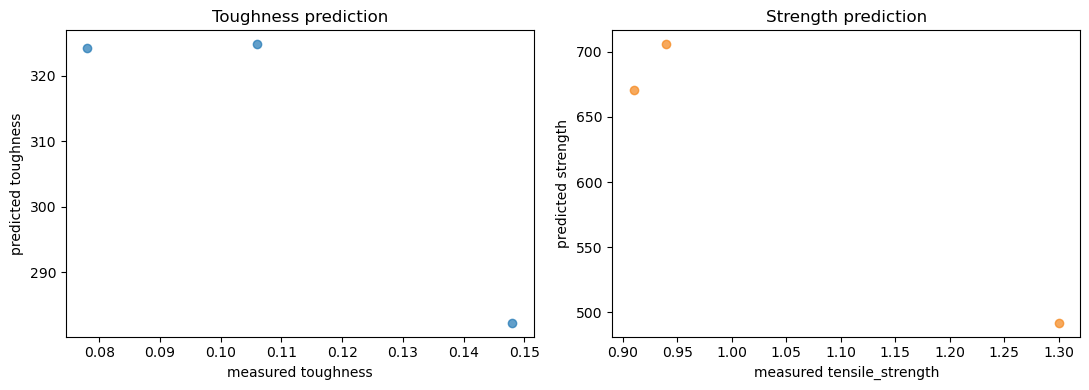

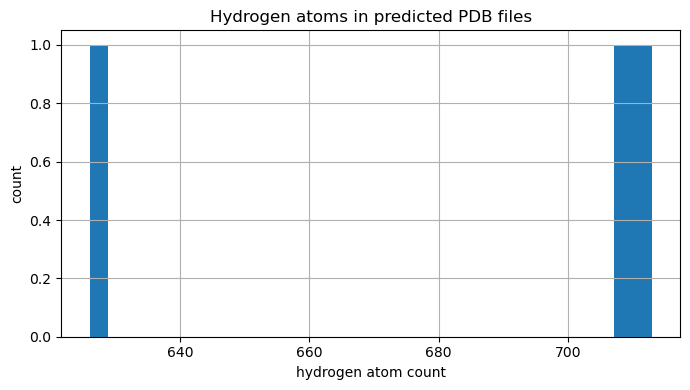

In [8]:
if len(pred_df):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(pred_df['measured_toughness'], pred_df['predicted_toughness'], alpha=0.7)
    axes[0].set_xlabel('measured toughness')
    axes[0].set_ylabel('predicted toughness')
    axes[0].set_title('Toughness prediction')
    axes[1].scatter(pred_df['measured_tensile_strength'], pred_df['predicted_strength'], alpha=0.7, color='#F58518')
    axes[1].set_xlabel('measured tensile_strength')
    axes[1].set_ylabel('predicted strength')
    axes[1].set_title('Strength prediction')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / 'prediction_vs_measured_scatter.png', dpi=200)
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    pred_df['hydrogen_atom_count'].fillna(0).hist(ax=ax, bins=30)
    ax.set_title('Hydrogen atoms in predicted PDB files')
    ax.set_xlabel('hydrogen atom count')
    ax.set_ylabel('count')
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / 'predicted_pdb_hydrogen_count.png', dpi=200)
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.axis('off')
    ax.text(
        0.02, 0.68,
        'No ColabFold PDB files were available in this run.',
        fontsize=14,
        weight='bold',
    )
    message = 'ColabFold parameter download is required before structure prediction.\nAfter predicted PDB files are generated, rerun sections 4-7.'
    ax.text(0.02, 0.42, message, fontsize=11)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / 'prediction_status_no_pdb.png', dpi=200)
    plt.show()


## 8. Summary and interpretation


In [9]:
run_summary = {
    **summary,
    'colabfold_selected_sequences': int(len(colab_input_df)),
    'predicted_pdb_files_found': int(len(pdb_df)),
    'prediction_rows': int(len(pred_df)),
    'figures_dir': str(FIGURE_DIR),
    'tables_dir': str(TABLE_DIR),
    'colabfold_data_dir': str(COLABFOLD_DATA_DIR),
    'notes': [
        'Full matched sequence set is large; ColabFold should be run in controlled batches.',
        'If AlphaFold parameters are missing, ColabFold downloads approximately 3.47 GB.',
        'Amber-relaxed ColabFold PDBs are preferred because the hbond predictor expects explicit hydrogens.',
    ],
}
(OUT_DIR / 'evaluation_summary.json').write_text(json.dumps(run_summary, indent=2, ensure_ascii=False), encoding='utf-8')
print(json.dumps(run_summary, indent=2, ensure_ascii=False))


{
  "n_mechanical_rows": 446,
  "n_rows_with_toughness_and_tensile_strength": 393,
  "n_matched_sequences": 3513,
  "n_matched_idv": 268,
  "sequence_length_min": 79,
  "sequence_length_max": 1854,
  "sequence_length_mean": 490.32678622260175,
  "colabfold_selected_sequences": 3,
  "predicted_pdb_files_found": 3,
  "prediction_rows": 3,
  "figures_dir": "/mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/figures",
  "tables_dir": "/mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/tables",
  "colabfold_data_dir": "/mnt/nas/jianquanzhao/gits/Mechanical-protein-RL/output/evaluate-mechanical-predictor/colabfold-local-data",
  "notes": [
    "Full matched sequence set is large; ColabFold should be run in controlled batches.",
    "If AlphaFold parameters are missing, ColabFold downloads approximately 3.47 GB.",
    "Amber-relaxed ColabFold PDBs are preferred because the hbond predictor expects explicit hydrogens."
  ]
}
